# Лабораторная работа №1
## Рекурсия. Последовательность Фибоначчи.

- Провести сравнительный анализ вычисление N-го элемента последовательности Фибоначчи с использованием рекурсивного алгоритма и итерационного процесса.
- Рекурсия не усечённая, а классическая. То есть должна быть чистая - без модернизации, return вызываем последовательно, без увеличения лимита.
- Максиму 40 элементов.
- График с расчетом времени каждого элемента.
- Слева итерации, справа рекурсия - 2 графика на 1 холсте.

Итоги работы - график, который зависит от входных данных

In [7]:
import time
import matplotlib.pyplot as plt

Функция поиска N-го элемента рекурсивным методом

In [8]:
def fibonacci_recursive(n):
    if n <= 1:
        return n
    return fibonacci_recursive(n-1) + fibonacci_recursive(n-2)

Функция поиска N-го элемента итерационным методом

In [9]:
def fibonacci_iterative(n):
    if n <= 1:
        return n
    
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

Функция расчёта времени выполнения 

In [10]:
def measure_time(func, n):
    start_time = time.perf_counter()
    result = func(n)
    end_time = time.perf_counter()
    return result, (end_time - start_time) * 1000

In [11]:
max_n = 40
recursive_times = []
iterative_times = []
n_values = list(range(1, max_n + 1))

print("-" * 60)
print(f"{'n':>3} | {'Рекурсивно (мс)':>15} | {'Итерационно (мс)':>15} | {'Значение':>15}")
print("-" * 60)

for n in n_values:
    value, iter_time = measure_time(fibonacci_iterative, n)
    iterative_times.append(iter_time)
    
    _, rec_time = measure_time(fibonacci_recursive, n)
    recursive_times.append(rec_time)
    
    print(f"{n:3} | {rec_time:15.6f} | {iter_time:15.6f} | {value:15}")

print("-" * 60)

------------------------------------------------------------
  n | Рекурсивно (мс) | Итерационно (мс) |        Значение
------------------------------------------------------------
  1 |        0.000800 |        0.001200 |               1
  2 |        0.001400 |        0.003400 |               1
  3 |        0.002700 |        0.001100 |               2
  4 |        0.002400 |        0.002200 |               3
  5 |        0.002200 |        0.002200 |               5
  6 |        0.002900 |        0.001400 |               8
  7 |        0.004200 |        0.001000 |              13
  8 |        0.005400 |        0.000900 |              21
  9 |        0.010500 |        0.000900 |              34
 10 |        0.017500 |        0.003900 |              55
 11 |        0.025100 |        0.001500 |              89
 12 |        0.039700 |        0.001400 |             144
 13 |        0.062700 |        0.001500 |             233
 14 |        0.108900 |        0.001600 |             377
 15 |  

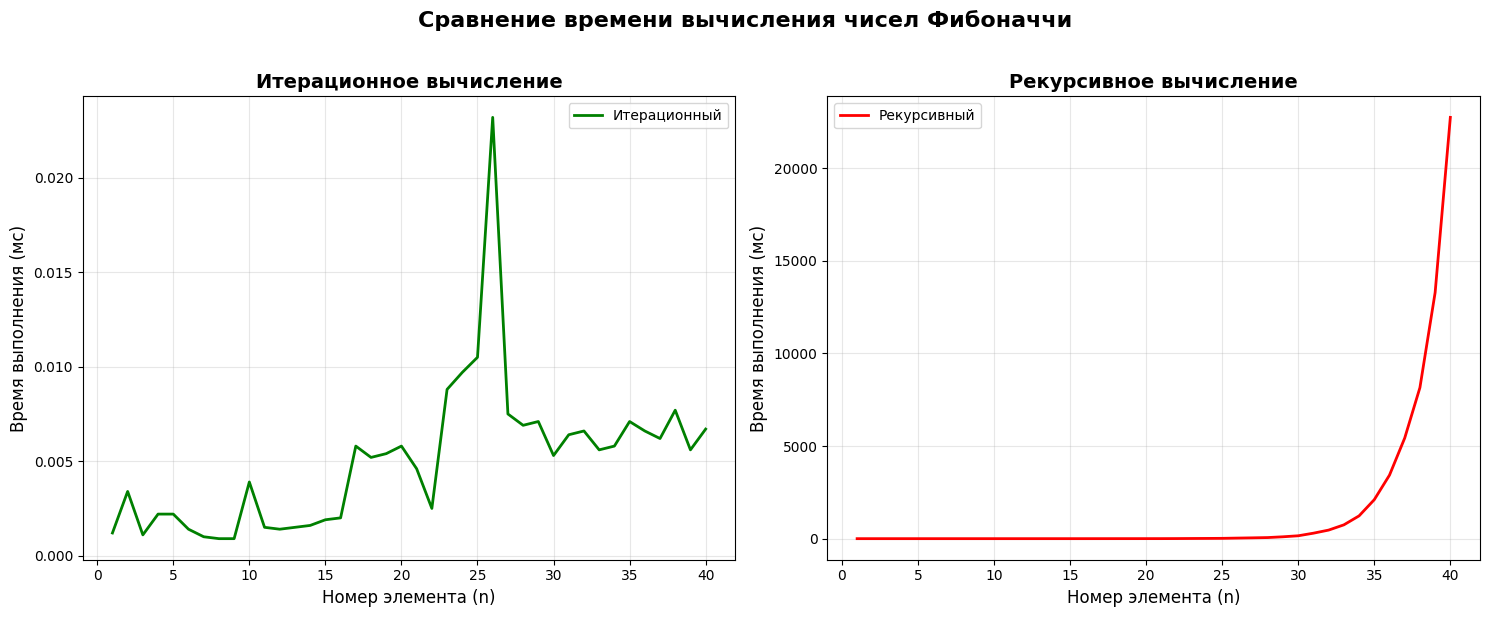

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(n_values, iterative_times, 'g-', linewidth=2, label='Итерационный')
ax1.set_xlabel('Номер элемента (n)', fontsize=12)
ax1.set_ylabel('Время выполнения (мс)', fontsize=12)
ax1.set_title('Итерационное вычисление', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(n_values, recursive_times, 'r-', linewidth=2, label='Рекурсивный')
ax2.set_xlabel('Номер элемента (n)', fontsize=12)
ax2.set_ylabel('Время выполнения (мс)', fontsize=12)
ax2.set_title('Рекурсивное вычисление', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle('Сравнение времени вычисления чисел Фибоначчи', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('fibonacci_comparison.png', dpi=150, bbox_inches='tight')
plt.show()